# Chapter 47: Medical Imaging Patterns

**How far does image-level cross-validation overstate the score on new patients, and does grouping by patient remove the error?**

Several images, slides or tiles usually share one patient. The chapter's rule is to keep each patient in one validation fold; the size of the error it prevents depends on how many images each patient contributes, which this demonstration varies.

*Constructed data with patient-level labels; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Constructed cohorts of 150 patients with a patient-level label (half positive). Each image has 12 features: the patient's own anatomy (shared by all of their images and larger than the within-patient noise), a weak disease signal on three features, and image noise. An extremely randomized trees classifier is scored by out-of-fold AUC pooled over five folds, split two ways: ordinary shuffled folds that treat each image alone, and GroupKFold by patient. Both are compared with the same model's AUC on 600 fresh patients, averaged over 8 cohorts. The control is the number of images per patient.

In [1]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold, KFold

from kaggle_companion.activities._common import clean

SEED = 47
DRAWS = 8            # independent cohorts; every estimate is a mean over draws
PATIENTS = 150       # development patients; 600 further patients form the fresh test cohort
FRESH = 600
DIM = 12             # image features


def generate(n_patients, images_each, rng):
    """Patient-level label. Each image = the patient's own anatomy (shared by all their images) + a weak disease signal + image noise."""
    label = (rng.random(n_patients) < 0.5).astype(int)
    anatomy = 1.5 * rng.normal(size=(n_patients, DIM))
    patient = np.repeat(np.arange(n_patients), images_each)
    y = label[patient]
    X = anatomy[patient] + 0.8 * rng.normal(size=(len(patient), DIM))
    X[:, :3] += 0.5 * (2 * y[:, None] - 1)
    return X, y, patient


def model(seed=0):
    return ExtraTreesClassifier(n_estimators=40, max_features=0.5, random_state=seed, n_jobs=1)


def pooled_auc(X, y, splits):
    """Out-of-fold probabilities pooled over all folds, then one AUC."""
    oof = np.zeros(len(y))
    for fit, hold in splits:
        oof[hold] = model().fit(X[fit], y[fit]).predict_proba(X[hold])[:, 1]
    return roc_auc_score(y, oof)


def run(images_per_patient):
    rng = np.random.default_rng(SEED)
    X_new, y_new, _ = generate(FRESH, images_per_patient, rng)       # fresh patients: the truth the CV should predict
    rows = {k: [] for k in ("kfold", "grouped", "fresh", "overlap_kfold", "overlap_grouped")}
    for draw in range(DRAWS):
        X, y, patient = generate(PATIENTS, images_per_patient, rng)
        kfold = list(KFold(5, shuffle=True, random_state=draw).split(X))              # each image on its own
        grouped = list(GroupKFold(5).split(X, y, patient))                              # whole patients together
        rows["kfold"].append(pooled_auc(X, y, kfold))
        rows["grouped"].append(pooled_auc(X, y, grouped))
        rows["fresh"].append(roc_auc_score(y_new, model().fit(X, y).predict_proba(X_new)[:, 1]))
        # The chapter's check: do validation patients also appear in training? (share of validation images)
        rows["overlap_kfold"].append(np.mean([np.isin(patient[b], patient[a]).mean() for a, b in kfold]))
        rows["overlap_grouped"].append(np.mean([np.isin(patient[b], patient[a]).mean() for a, b in grouped]))
    mean = {k: float(np.mean(v)) for k, v in rows.items()}
    return clean({
        "images_per_patient": images_per_patient, **mean,
        "kfold_error": mean["kfold"] - mean["fresh"], "grouped_error": mean["grouped"] - mean["fresh"],
        "per_draw": {k: rows[k] for k in ("kfold", "grouped", "fresh")},
        "patients": PATIENTS, "images": PATIENTS * images_per_patient, "fresh_patients": FRESH, "draws": DRAWS,
    })


## Measure it across the control

The control is **images per patient**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch47 import explain

VALUES = [1, 2, 4, 8]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                                 1       2       4       8
Image-level 5-fold AUC                       0.700   0.791   0.874   0.924
Grouped AUC                                  0.701   0.683   0.674   0.667
AUC on fresh patients                        0.716   0.689   0.707   0.706
Image-level error                           -0.016  +0.101  +0.167  +0.218
Grouped error                               -0.015  -0.006  -0.033  -0.039
Patients shared across folds (image-level)    0.0%   81.4%   98.8%  100.0%


## Look at it

The figure shows the default setting, images per patient = 4.

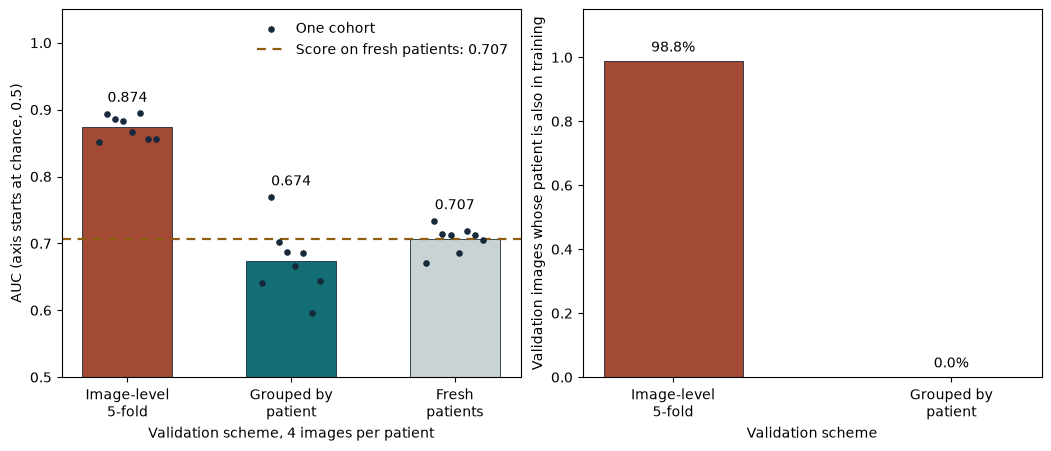

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch47 import draw, NCOLS, HEIGHT

DEFAULT = 4
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

With 4 images per patient the same model scores AUC 0.707 on fresh patients. Image-level folds report 0.874: 0.874 - 0.707 = 0.167 (their error). Grouped folds report 0.674, which is -0.033 from the fresh score. 98.8% of image-level validation images belong to a patient that is also in training, against 0.0% when grouped. The image-level number measures how well the model recognises patients it has already seen.

- Image-level: 0.874 - 0.707 = +0.167 (estimate minus fresh patients).
- Grouped by patient: 0.674 - 0.707 = -0.033.
- Image-level minus grouped: 0.874 - 0.674 = +0.200.
- Patient overlap between training and validation: 98.8% (image-level), 0.0% (grouped).

## Apply this to your competition

- Build the fold column from patient, study or slide identifiers, never from image rows, and keep it fixed for every model.
- Assert that no patient identifier appears in both a training fold and its validation fold.
- Report images per patient next to the score; the more repeats, the larger an image-level error can be.
- Check provenance for hidden links such as duplicate scans, shared slides or external data from the same patients.

Book location: Chapter 47, Keep all images from each patient in one validation fold.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)